In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

### Importando los datos

In [2]:
path_file = r"..\mediciones\clase2\clean\mediciones_parte2_clean.csv"

In [3]:
datos = pd.read_csv(path_file, sep=",")
datos.head(5)

,vpp_emisor,vpp_receptor,vpp_emisor_error,vpp_receptor_error
0,1.0,0.70,0.03,0.02
1,2.0,1.34,0.06,0.04
2,3.0,2.02,0.09,0.06
3,4.0,2.60,0.10,0.08
4,5.0,3.16,0.10,0.09


### Funciones

In [4]:
def funcion_lineal(x, m, b):
    return m * x + b

In [5]:
def ajuste_lineal_ponderados(x, y, y_error, funcion):
    """
    Ajuste lineal ponderado a los datos (x, y) con errores y_error.
    
    Parámetros:
    x : array_like
        Valores de la variable independiente.
    y : array_like
        Valores de la variable dependiente.
    y_error : array_like
        Errores asociados a los valores de y.
    funcion : callable
        Función modelo a ajustar.

    Retorna:
    popt : array
        Parámetros óptimos del ajuste (pendiente, intercepto).
    pcov : 2D array
        Matriz de covarianza de los parámetros ajustados.
    """

    # Realizar el ajuste ponderado
    popt, pcov = curve_fit(
        funcion, 
        x,
        y,
        sigma=y_error,
        absolute_sigma=True
    )
    
    return popt, pcov

In [6]:
def metricas_ajuste(x, y, y_err, popt, funcion_modelo):
    """
    Calcula R^2, Chi^2 y Chi^2 reducido para un ajuste.
    
    Parámetros:
    - x, y: Datos de entrada (array-like).
    - y_err: Incertidumbres en Y (array-like).
    - popt: Lista de parámetros optimizados devueltos por curve_fit.
    - funcion_modelo: La función usada en curve_fit (ej. recta).
    """
    x = np.array(x)
    y = np.array(y)
    y_err = np.array(y_err)
    
    # Valore predichos por el modelo
    y_pred = funcion_modelo(x, *popt)
    
    # 1. Residuales
    residuos = y - y_pred
    
    # 2. Coeficiente de Determinación R^2
    ss_res = np.sum(residuos**2)                  # Suma de cuadrados residual
    ss_tot = np.sum((y - np.mean(y))**2)         # Suma de cuadrados total
    r2 = 1 - (ss_res / ss_tot)
    
    # 3. Chi-cuadrado (Chi2)
    chi2 = np.sum((residuos / y_err)**2)
    
    # 4. Grados de libertad (nu = n - p)
    # n: número de datos, p: número de parámetros ajustados
    n = len(y)
    p = len(popt)
    dof = n - p
    
    # 5. Chi-cuadrado reducido (Chi2_nu)
    chi2_red = chi2 / dof if dof > 0 else np.nan
    
    return {
        "R2": r2,
        "Chi2": chi2,
        "Grados_Libertad": dof,
        "Chi2_reducido": chi2_red
    }

### Gráficamos las mediciones observadas

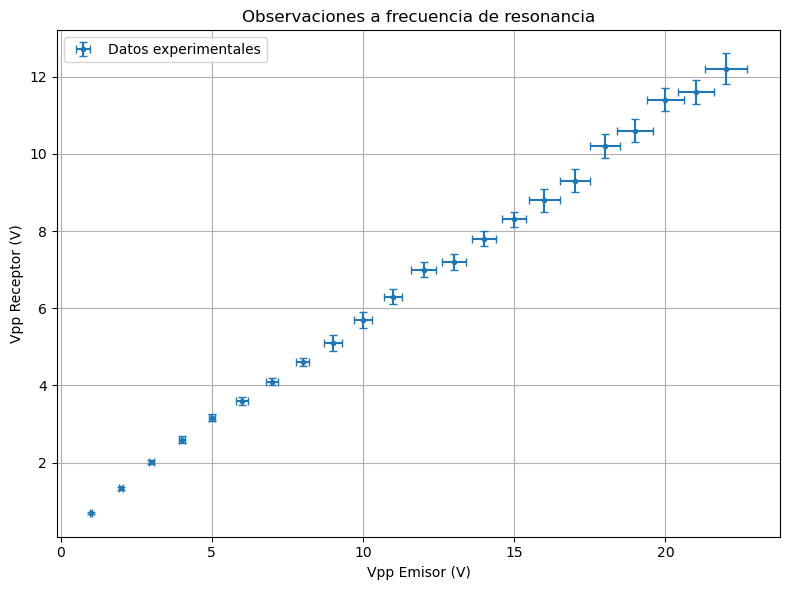

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    x=datos["vpp_emisor"],
    y=datos["vpp_receptor"],
    yerr=datos["vpp_receptor_error"],
    xerr=datos["vpp_emisor_error"],
    fmt='.',
    capsize=3,
    label='Datos experimentales',
)

ax.set_title("Observaciones a frecuencia de resonancia")
ax.set_xlabel("Vpp Emisor (V)")
ax.set_ylabel("Vpp Receptor (V)")
ax.legend()
ax.grid(True)
plt.tight_layout()

# guardamos 
path_save = r"..\graficos\clase2\observaciones_parte2.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

# Ajuste final
plt.show()

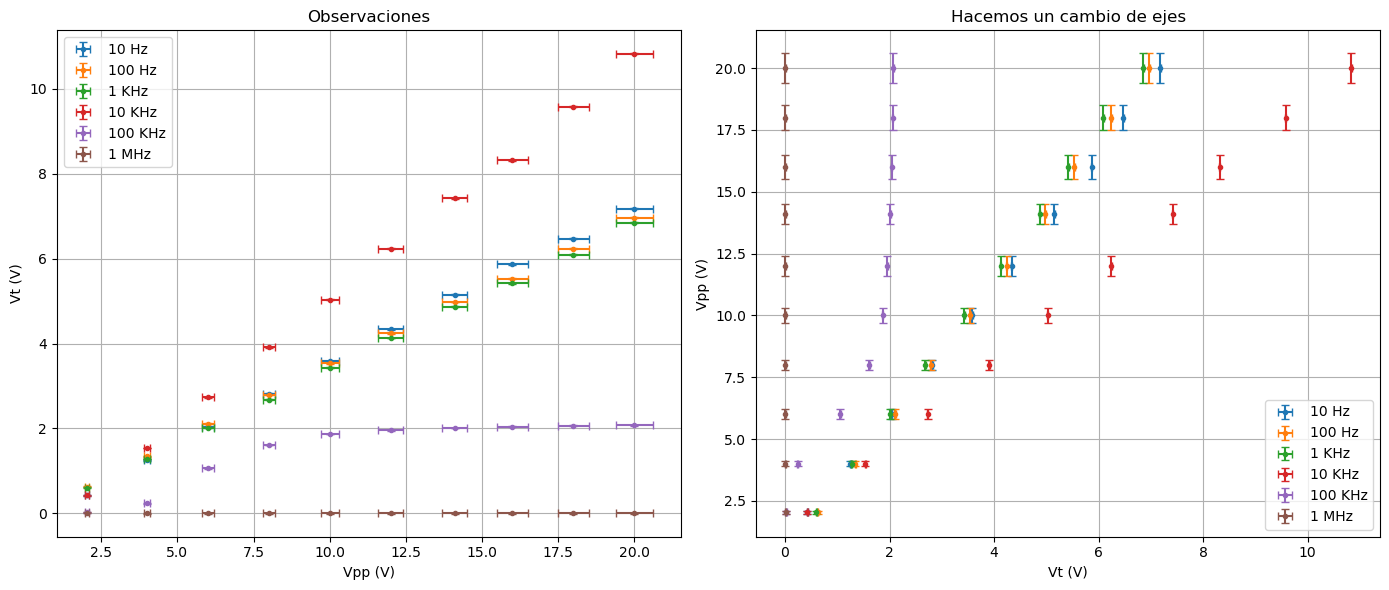

In [8]:
# 1 fila, 2 columnas (puedes ajustar el tamaño general con figsize)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1 (Izquierda: axes[0]) ---
# Este es el gráfico que ya tenías escrito
for label, vt in datos.iloc[:, 2:8].items():
    axes[0].errorbar(
        x=datos["vpp"],
        y=vt,
        yerr=datos["vt_error"],
        xerr=datos["vpp_error"],
        fmt='.',
        capsize=3,
        label=label
    )

axes[0].set_title("Observaciones")
axes[0].set_xlabel("Vpp (V)")
axes[0].set_ylabel("Vt (V)")
axes[0].legend()
axes[0].grid(True)

# --- GRÁFICO 2 (Derecha: axes[1]) ---
# Este es el gráfico que ya tenías escrito
for label, vt in datos.iloc[:, 2:8].items():
    axes[1].errorbar(
        x=vt,
        y=datos["vpp"],
        yerr=datos["vpp_error"],
        xerr=datos["vt_error"],
        fmt='.',
        capsize=3,
        label=label
    )

axes[1].set_title("Hacemos un cambio de ejes")
axes[1].set_xlabel("Vt (V)")
axes[1].set_ylabel("Vpp (V)")
axes[1].legend()
axes[1].grid(True)

# guardamos 
path_save = r"..\graficos\clase1\observaciones.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

# Ajuste final
plt.tight_layout()
plt.show()

### Ajuste Lineal

### El modelo: Vpp = m.Vt + b

realizamos un cambio de ejes. Y = Vpp, X = Vt

In [ ]:
resultados = pd.DataFrame(columns=["frecuencia", "m", "b", "m_error", "b_error", "Cov","R2", "Chi2", "Chi2_reducido"])

In [10]:
for freq, datos_col in datos.iloc[:, 2:8].items():
    popt, pcov = ajuste_lineal_ponderados(datos[freq], datos["vpp"], datos["vpp_error"], funcion_lineal)
    m, b = popt
    cov = pcov[0][1]  # Covarianza entre m y b
    m_error, b_error = np.sqrt(pcov[0][0]), np.sqrt(pcov[1][1])

    metrics = metricas_ajuste(datos[freq], datos["vpp"], datos["vpp_error"], popt, funcion_lineal)

    resultados.loc[len(resultados)] = {
        "frecuencia": freq,
        "m": m,
        "b": b,
        "m_error": m_error,
        "b_error": b_error,
        "Cov": cov,
        "R2": metrics["R2"],
        "Chi2": metrics["Chi2"],
        "Chi2_reducido": metrics["Chi2_reducido"],
    }

In [10]:
datos.head(5)

,vpp_emisor,vpp_receptor,vpp_emisor_error,vpp_receptor_error
0,1.0,0.70,0.03,0.02
1,2.0,1.34,0.06,0.04
2,3.0,2.02,0.09,0.06
3,4.0,2.60,0.10,0.08
4,5.0,3.16,0.10,0.09


### Agregamos uno en uno

In [8]:
resultados = pd.DataFrame(columns=["tipo", "m", "b", "m_error", "b_error", "Cov","R2", "Chi2", "Chi2_reducido", "grados_libertad"])

In [19]:
popt, pcov = ajuste_lineal_ponderados(datos["vpp_emisor"][:-2], datos["vpp_receptor"][:-2], datos["vpp_receptor_error"][:-2], funcion_lineal)
m, b = popt
m_error, b_error = np.sqrt(pcov[0][0]), np.sqrt(pcov[1][1])
cov = pcov[0][1]  # Covarianza entre m y b

In [20]:
metrics = metricas_ajuste(datos["vpp_emisor"][:-2], datos["vpp_receptor"][:-2], datos["vpp_receptor_error"][:-2], popt, funcion_lineal)

In [21]:
resultados.loc[len(resultados)] = {
        "tipo": "b libre",
        "m": m,
        "b": b,
        "m_error": m_error,
        "b_error": b_error,
        "Cov": cov,
        "R2": metrics["R2"],
        "Chi2": metrics["Chi2"],
        "Chi2_reducido": metrics["Chi2_reducido"],
        "grados_libertad": metrics["Grados_Libertad"]
    }

In [22]:
resultados

,tipo,m,b,m_error,b_error,Cov,R2,Chi2,Chi2_reducido,grados_libertad
0,b libre,0.554765,0.189500,0.004507,0.019592,-0.000055,0.997855,31.616359,1.580818,20
1,b libre,0.555266,0.188453,0.004618,0.019704,-0.000057,0.997622,31.368232,1.650960,19
2,b libre,0.556445,0.186024,0.004814,0.019902,-0.000061,0.997392,30.617370,1.700965,18


### Funcion Lineal sin ordenada, b=0 

In [26]:
def funcion_lineal_con_b_cero(x, m):
    return m * x

In [27]:
popt, pcov = ajuste_lineal_ponderados(datos["vpp_emisor"][:], datos["vpp_receptor"][:], datos["vpp_receptor_error"][:], funcion_lineal_con_b_cero)
popt, pcov

(array([0.58178637]), array([[1.25121164e-05]]))

In [28]:
m = popt[0]
m_error = np.sqrt(pcov[0][0])

In [29]:
m, m_error

(np.float64(0.5817863748542695), np.float64(0.003537247013080396))

In [30]:
metrics = metricas_ajuste(datos["vpp_emisor"][:], datos["vpp_receptor"][:], datos["vpp_receptor_error"][:], popt, funcion_lineal_con_b_cero)

In [31]:
resultados.loc[len(resultados)] = {
        "tipo": "b fijo",
        "m": m,
        "b": 0,
        "m_error": m_error,
        "b_error": 0,
        "Cov": 0,
        "R2": metrics["R2"],
        "Chi2": metrics["Chi2"],
        "Chi2_reducido": metrics["Chi2_reducido"],
        "grados_libertad": metrics["Grados_Libertad"]
    }

In [33]:
resultados

,tipo,m,b,m_error,b_error,Cov,R2,Chi2,Chi2_reducido,grados_libertad
0,b libre,0.554765,0.189500,0.004507,0.019592,-0.000055,0.997855,31.616359,1.580818,20
1,b libre,0.555266,0.188453,0.004618,0.019704,-0.000057,0.997622,31.368232,1.650960,19
2,b libre,0.556445,0.186024,0.004814,0.019902,-0.000061,0.997392,30.617370,1.700965,18
3,b fijo,0.581786,0.000000,0.003537,0.000000,0.000000,0.990604,125.175080,5.960718,21


### Ajuste lineal efectivo

In [38]:
datos.head(5)

,vpp_emisor,vpp_receptor,vpp_emisor_error,vpp_receptor_error
0,1.0,0.70,0.03,0.02
1,2.0,1.34,0.06,0.04
2,3.0,2.02,0.09,0.06
3,4.0,2.60,0.10,0.08
4,5.0,3.16,0.10,0.09


In [69]:
# PASO 1: Ajuste preliminar considerando solo sy (para obtener una m aproximada)
m_estimada = resultados["m"][2]

In [70]:
# PASO 2: Cálculo de la incertidumbre efectiva
incerteza_efectiva = np.sqrt(datos["vpp_receptor_error"][:-2]**2 + (m_estimada * datos["vpp_emisor_error"][:-2]) ** 2)

In [71]:
# PASO 3: Ajuste final ponderado por s_efectiva
popt, pcov = curve_fit(funcion_lineal, datos["vpp_emisor"][:-2], datos["vpp_receptor"][:-2], sigma=incerteza_efectiva, absolute_sigma=True)

In [72]:
m, b = popt
m_error, b_error = np.sqrt(pcov[0][0]), np.sqrt(pcov[1][1])
cov = pcov[0][1]  # Covarianza entre m y b

In [73]:
metrics = metricas_ajuste(datos["vpp_emisor"][:-2], datos["vpp_receptor"][:-2], incerteza_efectiva, popt, funcion_lineal)

In [74]:
resultados.loc[len(resultados)] = {
        "tipo": "b libre-ef",
        "m": m,
        "b": b,
        "m_error": m_error,
        "b_error": b_error,
        "Cov": cov,
        "R2": metrics["R2"],
        "Chi2": metrics["Chi2"],
        "Chi2_reducido": metrics["Chi2_reducido"],
        "grados_libertad": metrics["Grados_Libertad"]
    }

### Guardamos

In [58]:
resultados = resultados.iloc[:-1]

In [77]:
resultados

,tipo,m,b,m_error,b_error,Cov,R2,Chi2,Chi2_reducido,grados_libertad
0,b libre,0.554765,0.189500,0.004507,0.019592,-0.000055,0.997855,31.616359,1.580818,20
1,b libre,0.555266,0.188453,0.004618,0.019704,-0.000057,0.997622,31.368232,1.650960,19
2,b libre,0.556445,0.186024,0.004814,0.019902,-0.000061,0.997392,30.617370,1.700965,18
3,b fijo,0.581786,0.000000,0.003537,0.000000,0.000000,0.990604,125.175080,5.960718,21
4,b libre-ef,0.556375,0.188226,0.006367,0.025799,-0.000103,0.997542,18.871603,0.943580,20
5,b libre-ef,0.556987,0.186992,0.006531,0.025965,-0.000107,0.997284,18.694653,0.983929,19
6,b libre-ef,0.558198,0.184589,0.006793,0.026253,-0.000114,0.997041,18.217875,1.012104,18


In [78]:
path_ajuste = r".\clase2\ajuste_lineal_parte2_resultados.csv"
resultados.to_csv(path_ajuste, index=False)